# v1.1.3: Example 3 Soft Photon Evolution

In [8]:
%reload_ext autoreload
%autoreload 2

import sys
import numpy as np
import astropy.units as u
import astropy.constants as c
from scipy.interpolate import interp1d

sys.path.append("../..")
from darkhistory.main import evolve
from darkhistory.config import load_data
from darkhistory.spec.spectrum import Spectrum
import darkhistory.physics as phys

import matplotlib as mpl
import matplotlib.pyplot as plt
# mpl.rc_file("../matplotlibrc")

# Test evolve

In [2]:
# Zero injection functions for baseline solution
photE = load_data('binning')['photeng']
elecEk = load_data('binning')['eleceng']
zero_phot_spec = Spectrum(photE, photE*0, spec_type='dNdE')
zero_elec_spec = Spectrum(elecEk, elecEk*0, spec_type='dNdE')

def zero_in_spec_phot(*args, **kwargs):
    return zero_phot_spec

def zero_in_spec_elec(*args, **kwargs):
    return zero_elec_spec

def zero_rate_func_N(*args, **kwargs):
    return 1e-100

def zero_rate_func_eng(*args, **kwargs):
    return 1e-100

In [5]:
soln_base = evolve(
    in_spec_phot  = zero_in_spec_phot, # [phot / inj]
    in_spec_elec  = zero_in_spec_elec, # [elec / inj]
    rate_func_N   = zero_rate_func_N,  # [inj / pcm^3 s]
    rate_func_eng = zero_rate_func_eng, # [eV / pcm^3 s]
    start_rs = 3000, end_rs = 100, coarsen_factor = 1, verbose = 1,
    clean_up_tf = False,
    reion_switch = True,
)
h = soln_base['softphot_hist'].history

[2025-10-03 12:22:43,623] INFO: darkhistory.config: Loaded deposition transfer functions.
[2025-10-03 12:22:47,895] INFO: darkhistory.config: Loaded ICS transfer functions.
  0%|          | 9/3402 [00:00<00:37, 89.76it/s]

Inject!


  1%|          | 29/3402 [00:00<01:37, 34.68it/s]C:\Users\berki\OneDrive\Desktop\GradSchool\Softphoton\DarkHistory\darkhistory\soft_photons\soft_photons.py:225: RuntimeWarning: overflow encountered in multiply
  return - Lambda_BR * (1-np.exp(-xT_e)) / xT_e**3 * self.spec.n + get_S_Y(z, x, T_M) + get_S_ff_bb(z, x, T_M)
C:\Users\berki\OneDrive\Desktop\GradSchool\Softphoton\DarkHistory\darkhistory\soft_photons\soft_photons.py:245: RuntimeWarning: invalid value encountered in add
  new_spec.n += dn
100%|██████████| 3402/3402 [00:52<00:00, 64.86it/s]


In [6]:
soln_base.keys()

dict_keys(['rs', 'x', 'Tm', 'highengphot', 'lowengphot', 'lowengelec', 'f', 'softphot_hist'])

findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern Roman
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern Roman
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern Roman
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern Roman
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern Roman
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern Roman
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern Roman
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern Roman
findfont: Generic family 'serif' not found because none of the following

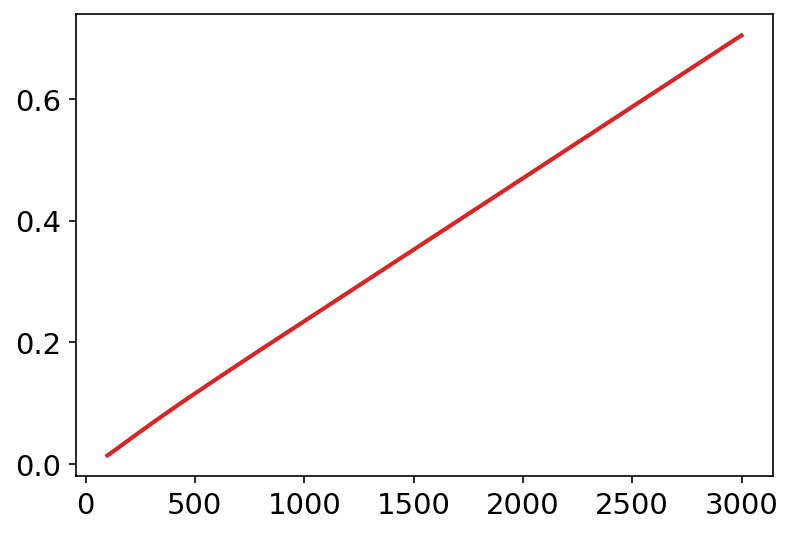

In [15]:
mpl.rcParams['text.usetex'] = False
plt.plot(soln_base['rs'], soln_base['Tm'])

In [16]:
z_arr = np.array([sd.z for sd in h])
n_arr = np.array([sd.n for sd in h])
n_interp = interp1d(z_arr, n_arr, kind='linear', bounds_error=True, axis=0)

findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern Roman
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern Roman
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern Roman
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern Roman
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern Roman
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern Roman
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern Roman
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern Roman
findfont: Generic family 'serif' not found because none of the following

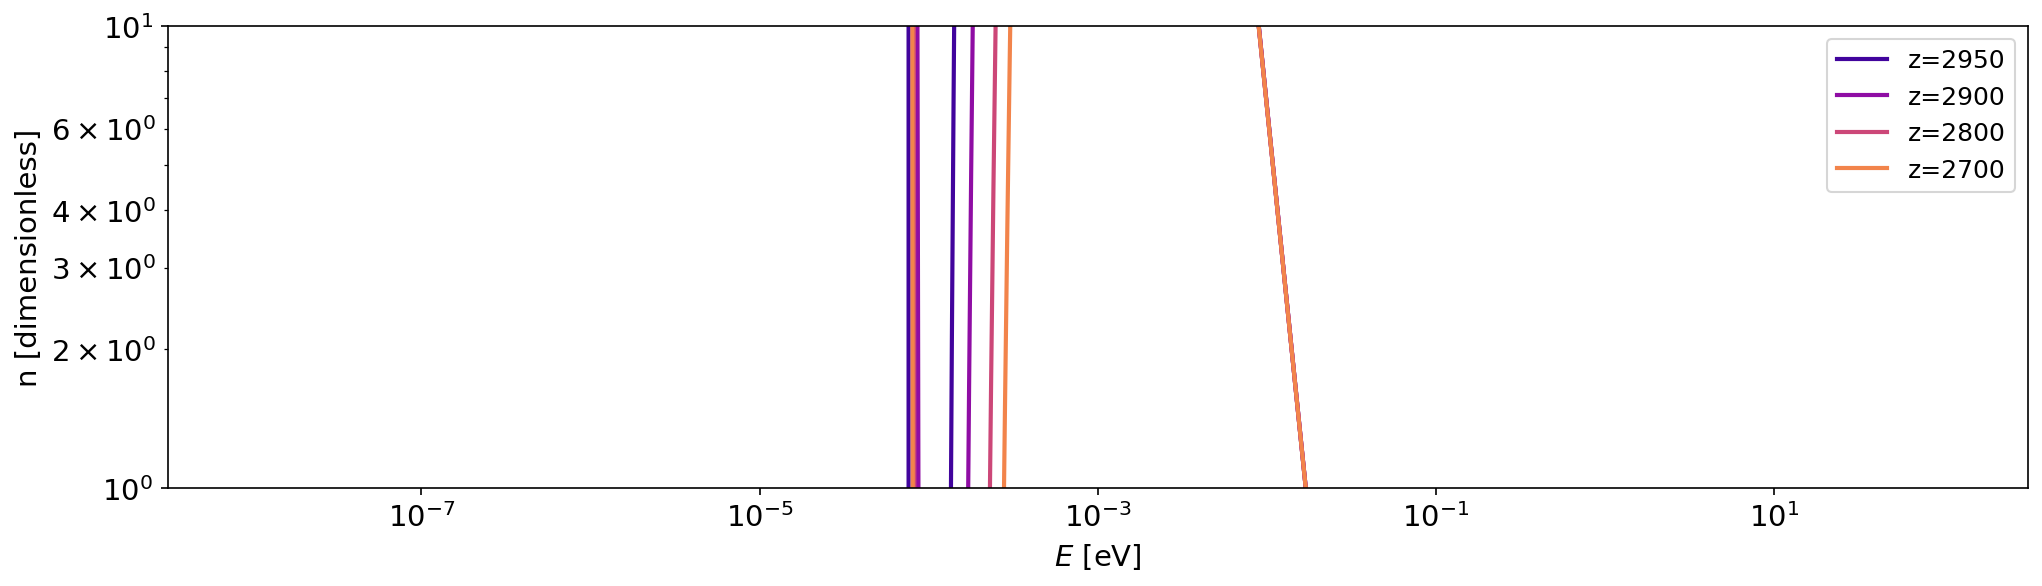

In [17]:
z_s = [2950, 2900, 2800, 2700]
color_s = mpl.colormaps['plasma']([0.1, 0.3, 0.5, 0.7])

fig, ax = plt.subplots(figsize=(16, 4))
sd = h[0]
for i_z, z in enumerate(z_s):
    ax.plot(sd.x, n_interp(z), label=f'z={z}', color=color_s[i_z])
ax.set(xlabel=r'$E$ [eV]', ylabel='n [dimensionless]')
ax.set(xscale='log', yscale='log')
ax.legend()

[(0.01, 100000.0)]

findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern Roman
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern Roman
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern Roman
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern Roman
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern Roman
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern Roman


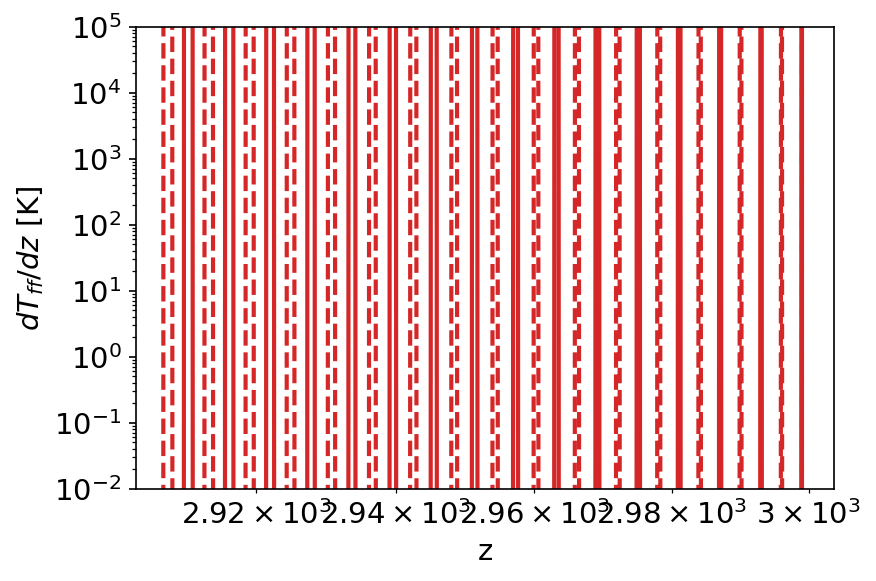

In [18]:
dTffdz_arr = soln_base['softphot_hist'].drhoffdz_arr
dTffdz_arr = (np.array(dTffdz_arr) * u.eV / c.k_B).to(u.K).value

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(z_arr, dTffdz_arr, color='C0')
ax.plot(z_arr, -dTffdz_arr, ls='--', color='C0')
ax.set(xlabel='z', ylabel=r'$dT_{ff}/dz$ [K]')
ax.set(xscale='log', yscale='log')
# ax.axvline(1500, color='k', lw=1)
ax.set(ylim=(1e-2, 1e5))

In [44]:
soln_base.keys()

dict_keys(['rs', 'x', 'Tm', 'highengphot', 'lowengphot', 'lowengelec', 'f', 'softphot_hist'])

In [49]:
soln_base['Tm'].shape

(5704,)

In [52]:
np.array([phys.TCMB(1+z) for z in z_arr[2:]]).shape

(5704,)

[None, None]

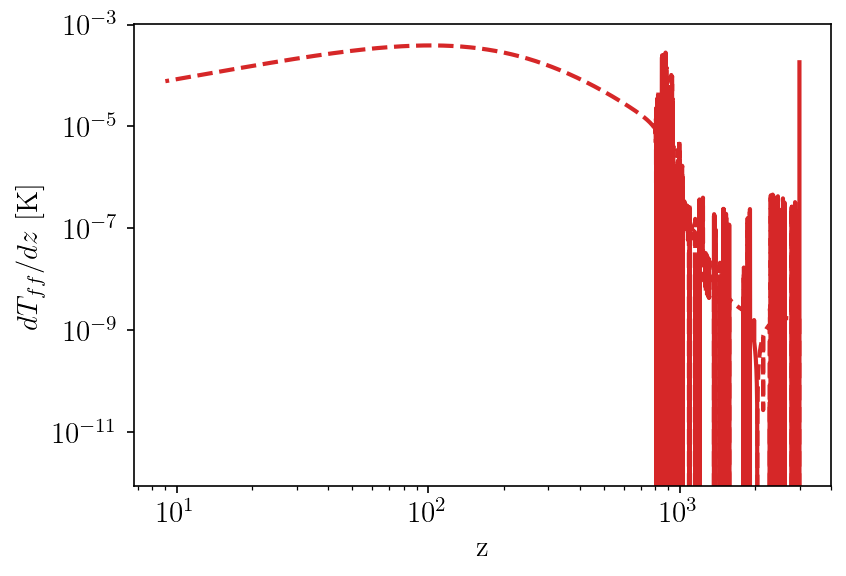

In [57]:
a = np.diff(soln_base['Tm'] / np.array([phys.TCMB(1+z) for z in z_arr[2:]]))

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(z_arr[3:], a, color='C0')
ax.plot(z_arr[3:], -a, ls='--', color='C0')
ax.set(xlabel='z', ylabel=r'$dT_{ff}/dz$ [K]')
ax.set(xscale='log', yscale='log')
# ax.axvline(1500, color='k', lw=1)
# ax.set(ylim=(1e-2, 1e5))

In [ ]:
for i in range(100):
    print(f'{h[i].z:.3f}, {h[i].tau:.6e}')

# MISC tests

In [ ]:
z = 10
n_H = phys.nH * (1 + z)**3 * (1/u.cm**3)
n_He = phys.nHe * (1 + z)**3 * (1/u.cm**3)
n_e = n_H * 0.5
prefactorEq14 = - 1 / (3/2 * (n_H + n_He + n_e))

T_CMB = phys.TCMB(1 + z) * u.eV
rho_CMB = (np.pi**2 / 15 * (T_CMB)**4 / (c.hbar**3 * c.c**3)).to(u.eV / u.cm**3)
T_M = 10 * u.eV
H = phys.hubble(z) * u.s**-1
prefactorEq15 = - rho_CMB / (np.pi**4/15) * (T_M/T_CMB)**3 * c.sigma_T * n_e * c.c / (H * (1 + z))

a = (prefactorEq14 * prefactorEq15 * 1).to(u.eV)

In [12]:
(a / u.eV).decompose()

<Quantity 3.36814609e+14>

In [13]:
prefactor.decompose()

<Quantity -0.03237836 kg / (m s2)>